## Домашнее задание 3 (10 баллов)

## НИУ ВШЭ, 2024-25 учебный год

## Формат сдачи

Сам ноутбук называйте в формате hw-03-USERNAME.ipynb, где USERNAME — ваши фамилия и имя. Файл надо будет сдать в anytask.

## О задании

В этом домашнем задании вы получите опыт подготовки данных и EDA (Exploratory Data Analysis), приблизившись к реальной работе с данными с помощью уже знакомых вам инструментов: numpy, pandas, matplotlib и seaborn, а также познакомитесь с plotly.

EDA - важный этап работы с данными. Именно в процессе EDA вы можете выяснить особенности датасета, найти зависимости в данных, протестировать гипотезы о взаимосвязях признаков и целевой переменной. В реальности вы сами будете определять, что и как проверять в рамках EDA, однако в данной работе гипотезы будут выдвинуты за вас автором задания. Также и типы графиков, которые вы будете использовать уже предопределены за вас. Выполняя задания по визуализациям, обращайте внимание на референсные картинки, которые были оставлены авторами. Они показывают, какой примерно результат от вас ожидается.

Это задание будет включать в себя построение некоторого количества графиков, потому вот основные правила, в соответствии с которыми графики должны быть оформлены:
1. Любой график всегда имеет название.
2. Оси у графика подписаны (исключение - график делит название оси с соседним).
3. Подписи делаются на одном языке (либо английский, либо русский), но не на их смеси.
4. Если вы выводите несколько графиков, то они размещаются в рамках одного объекта matplotlib.pyplot.figure. Вы не выводите графики последовательно, а смотрите, как их разместить сразу все за раз.
5. Отдельные графики (если графиков на картинке больше 1) также имеют свои названия.
6. Если на графике есть несколько различных объектов, то для их различения используется легенда. Помещайте легенду в место, где она в наименьшей мере мешает восприятию самого графика.
7. Если есть легенда, то она должна иметь навание, а также ее содержание должно быть адекватными (пожалейте проверяющих, они не хотят разбирать, а к чему относится зеленая линия, которая на легенде помечена меткой "0").
8. Используйте цветовые гаммы, чтобы объекты на графиках отличались цветом.
9. Текст на визуализации должен быть читаем. Если вы вывели названия категорий в качестве подписей на оси Х, а эти названия наезжают друг на друга, то вам нужно что-то с этим сделать. Нечитаемый или плохо читаемый (очень маленький, невероятно огромный) текст ведет к снижению баллов.

При работе с табличными данными используйте функционал [style](https://pandas.pydata.org/docs/user_guide/style.html#Builtin-Styles), чтобы визуально выделять необходимые элементы.

В этом задании будут оцениваться ваши развернутые комментарии, размышления и выводы (по построенным графикам): не скупитесь на них, но следите, чтобы выводы не были поверхностными и очевидными.

*Тут правило про плагиат, которое вам итак известно - обнуляются все работы, которые подозреваются в некорректных заимствованиях!* Помните, что просто скопировать код из интернета и указать источник - это не ваша самостоятельная работа, а автора кода. Измените хоть что-нибудь в коде.

## О данных

Будем работать с [датасетом физической активности](https://www.kaggle.com/datasets/uciml/human-activity-recognition-with-smartphones).

В этом датасете собраны данные 30 человек, выполняющих различные действия со смартфоном на поясе. Данные записывались с помощью датчиков (акселерометра и гироскопа) в этом смартфоне. Были зафиксированы: "3-осевое линейное ускорение" (_tAcc-XYZ_) и "3-осевая угловая скорость" (_tGyro-XYZ_).

1. Все сигналы отсортированы по времени, пропущены через фильтр шума.
2. Все наблюдения были разделены на окна по 128 сигналов в каждом, причем окна пересекаются на 50% (грубо говоря, с 1 по 128 сигнал в 1 окно, с 64 до 192 сигнала - во 2 окно и так далее). То есть каждое окно покрывает 2.56 секунды данных (два шага человека при ходьбе, учитывая медленную походку пожилых людей).
3. Линейное ускорение было разделено на две составляющие (с помощью низкочастотного фильтра): ускорение самого тела, а также гравитационная составляющая. Будем называть их ускорением тела и гравитационным ускорением.
4. К получившимся окнам применяли различные функции для получения следующих показателей:
    - max
    - min
    - mad (median)
    - mean
    - std
    - skewness (коэффициент асимметричности распределения признака в окне)
    - etc. (подробнее, на сколько это возможно, указано в [самой статье](https://www.esann.org/sites/default/files/proceedings/legacy/es2013-84.pdf))
5. Величина (magnitude) сигнала также определялась через евклидову норму всех значений из вектора для одного окна.
6. К окнам было применено преобразование Фурье, чтобы получить частоты. Из частот были извелченыте же показатели, плюс новые:
    - bandsEnergy (энергия частотного интервала)
7. Были посчитаны углы между векторами соответствующих окон.
8. Для ускорений были посчитаны производные - рывки, к которым применялись те же функции.

Итог: в датасете каждый признак - это какая-то операция над вектором из 128 чисел, которые соответствуют замерам определенного человека занятого какой-то активностью на протяжении 2.56 секунд.

Как читать названия признаков? Примеры:
- `tBodyAccMag-mean()` - это вектор ускорений тела (без гравитационной составляющей этого ускорения), из которого взяли евклидову норму, а затем усреднили, чтобы получить скаляр
- `fBodyAcc-bandsEnergy()-1,8.2` - это вектор ускорения тела, к которому применили преобразование Фурье, преобразовав его в вектор частот, а затем посчитали на этом векторе энергию данного частотного интервала в определенном диапазоне частот (в данном случае 1 - 8.2)
- `angle(X,gravityMean)` - это угол между осью Х и вектором усредненных значений гравитационного ускорения из соответствующего окна

Вероятно, сначала покажется сложным, но мы разберемся с некоторыми признаками в отдельности и вы сможете понять их смысл, уже исходя из фактических соотношений.

## Предобработка данных

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

import warnings
warnings.filterwarnings("ignore")

In [53]:
train = pd.read_csv('train.csv.zip')
test = pd.read_csv("test.csv.zip")

In [54]:
train.shape

(7352, 563)

В датасете 563 признака, включая целевую переменную. Столько признаков нам не нужно. Мы за вас сделали подвыборку признаков для удобства работы с ними.

In [55]:
cols_subset = [
    'tBodyAccMag-mean()',  # усредненная величина ускорения тела
    'tBodyGyroJerk-mad()-X',  # медианная величина рывка тела по оси Х
    'tGravityAcc-min()-X',  # минимум гравитационной составляющей ускорения по оси Х
    'tBodyAcc-max()-X',  # максимальная величина ускорения тела по оси Х
    'fBodyAcc-bandsEnergy()-1,8.2',  # энергия ускорения тела в интервале частоты
    'angle(X,gravityMean)',  # угол между осью Х и усредненной гравитационной составляющей ускорения
    'angle(Y,gravityMean)',  # угол между осью Y и усредненной гравитационной составляющей ускорения
    'angle(Z,gravityMean)',  # угол между осью Z и усредненной гравитационной составляющей ускорения,
    'fBodyAcc-skewness()-X',  # асимметричность частоты ускорения тела по оси Х
    'subject',  # номер испытуемого
    'Activity',  # название вида деятельности (целевая переменная)
]

In [56]:
train_new = train[cols_subset]
test_new = test[cols_subset]

### Задание 1 (0.5 балла)

Посмотрите на пропуски и дубли в данных train и test. Есть ли они? Если есть, напишите, с чем это может быть связано? Если нет, то просто напишите, что пропусков и/или дублей нет.

In [57]:
miss_tr = np.sum(train_new.isna().sum())
miss_te = np.sum(test_new.isna().sum())

duplic_tr = train_new.duplicated().sum()
duplic_ts = test_new.duplicated().sum()

miss_tr, miss_te, duplic_tr, duplic_ts, 


(np.int64(0), np.int64(0), np.int64(0), np.int64(0))

Пропусков и дублей нет в train и test.

### Задание 2 (0.5 балла)

Выведите основные статистики данных: среднее, медиана, перцентили (0.25, 0.5, 0.75), минимум, максимум, стандартное отклонение. Посмотрите на таблицу и напишите, видите ли вы в ней что-нибудь интересное.

In [58]:
train.describe()


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515,17.413085
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122,8.975143
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414,8.000000
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181,19.000000
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659,26.000000
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000,30.000000


Достаточно большое количество данных имеет сильный разброс значений. Например, fBodyAcc-bandsEnergy()-1,8.2 имеет стандартное отклонение = 2.234, более разбросанный признак, соответственно менее стабильный, а angle(X,gravityMean) уже со стандартным отклонением = 0.512, у него меньше разброс, они более стабильный. Можно заметить, что в train значения признаков в колонках  min и max ограничены интервалом от -1 до 1.

### Задание 3 (0.5 балла)

Данные сбалансированы? У вас есть 6 категорий активности (целевая переменная). Если одна из категорий представлена большим количеством наблюдений, а остальные - нет, то это обстоятельство, о котором хотелось бы знать заранее. Гиперболизированный пример: представьте, что у вас 1000 наблюдений, разделенных на два класса, и только 5 принадлежат ко второму классу. Как учить модель на такой выборке? Есть сильное подозрение, что многие модели будут склонны вырождаться в константу. Отсюда и необходимость проверять баланс классов.

Выведите количество наблюдений для всех категорий активности в train и test. Посчитайте разницу в процентах между самой крупной категорией и самой маленькой (самая большая категория - это 100%). Если разница (округленная до ближайшего целого числа) не превышает 30%, то давайте для наших целей считать, что данные сбалансированы. Напишите, сбалансированы ли данные в train и test.

In [59]:
observ = train_new[['Activity', 'subject']].groupby('Activity').count()
print(f'Количество наблюдений в train: {train_new["subject"].count()}')

cnt = train_new["Activity"].value_counts()
perc = (cnt / cnt.max() * 100).round()
difference = int(perc.max() - perc.min())

if difference <= 30:
    print(f'В train данные сбалансированы, разница {difference} %')
else:
    print(f'В train данные не сбалансированы, разница {difference} %')

Количество наблюдений в train: 7352
В train данные сбалансированы, разница 30 %


In [11]:
observ = test_new[['Activity', 'subject']].groupby('Activity').count()
print(f'Количество наблюдений в test: {test_new["subject"].count()}')

cnt = test_new["Activity"].value_counts()
perc = (cnt / cnt.max() * 100).round()
difference = int(perc.max() - perc.min())

if difference <= 30:
    print(f'В test данные сбалансированы, разница {difference} %')
else:
    print(f'В test данные не сбалансированы, разница {difference} %')

Количество наблюдений в test: 2947
В test данные сбалансированы, разница 22 %


### Задание 4 (0.5 балла)

Посчитайте корреляции всех признаков (включая таргет) со всеми другими. Какими получились значения? Есть идеи, почему так? Напишите ваши мысли.

In [61]:
correlat = train_new.corr(numeric_only=True)

correlat

,tBodyAccMag-mean(),tBodyGyroJerk-mad()-X,tGravityAcc-min()-X,tBodyAcc-max()-X,"fBodyAcc-bandsEnergy()-1,8.2","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",fBodyAcc-skewness()-X,subject
tBodyAccMag-mean(),1.000000,0.899080,0.369962,0.959827,0.697832,-0.370849,0.495561,0.426283,0.379796,-0.073652
tBodyGyroJerk-mad()-X,0.899080,1.000000,0.380118,0.879900,0.507939,-0.382246,0.478567,0.380967,0.266002,-0.110321
tGravityAcc-min()-X,0.369962,0.380118,1.000000,0.380404,0.239088,-0.988663,0.797116,0.667415,-0.261676,-0.042371
tBodyAcc-max()-X,0.959827,0.879900,0.380404,1.000000,0.613383,-0.384192,0.480229,0.405023,0.335708,-0.055633
"fBodyAcc-bandsEnergy()-1,8.2",0.697832,0.507939,0.239088,0.613383,1.000000,-0.213318,0.363170,0.423927,0.260316,-0.037000
"angle(X,gravityMean)",-0.370849,-0.382246,-0.988663,-0.384192,-0.213318,1.000000,-0.783848,-0.643655,0.265523,0.026137
"angle(Y,gravityMean)",0.495561,0.478567,0.797116,0.480229,0.363170,-0.783848,1.000000,0.594885,-0.046213,-0.009829
"angle(Z,gravityMean)",0.426283,0.380967,0.667415,0.405023,0.423927,-0.643655,0.594885,1.000000,-0.183815,-0.098712
fBodyAcc-skewness()-X,0.379796,0.266002,-0.261676,0.335708,0.260316,0.265523,-0.046213,-0.183815,1.000000,0.019742
subject,-0.073652,-0.110321,-0.042371,-0.055633,-0.037000,0.026137,-0.009829,-0.098712,0.019742,1.000000


Здесь сразу target мы посчитать не можем, так как 'Activity' это категориальная переменная, её нужно превратить в фиктивную, чтобы корреляция смогла её посчитать. Для этого мы можем обратиться к способу OneHotEncoding.
Уже сейчас можно сказать, что в привычной таблице корреляции по главной диагонали коэффициенты всегда будут равны 1, поскольку признак коррелирует с самим собой сильнее всего. 
В целом, можно увидеть, что одна группа признаков имеет высокую корреляцию (tBodyAccMag-mean(),tBodyGyroJerk-mad()-Х,tBodyAcc-max()-X). Это можно объяснить тем, что все эти признаки описывают интенсивность движения тела, его ускорение на оси Х.
И группа (tGravityAcc-min()-X и angle(X,gravityMean), angle(Y,gravityMean), angle(Z,gravityMean)) с низкой корреляцией. Между первыми двумя особенно сильная отрицательная корреляция (-0.988663), поскольку оба признака говорят об ориентации относительно гравитации. 
Условно, когда tGravityAcc-min()-X возрастает, тогда angle(X,gravityMean) убывает, и наоборот. Это можно увидеть из уравнения частного случая единичного вектора оси Х.
Остальные же 2 тоже связаны с гравитационной составляющей ускорения, так как это углы, из-за этого возникает их корреляция друг с другом.
Subject почти ни с чем не коррелирует, так как это не физическая величина и он почти не связан линейно с признаками.

делаю преобразование таргета для вычисления корреляции

In [60]:
dummy = train_new.copy()  
dummy = pd.get_dummies(dummy, columns=["Activity"], drop_first=False)
corr = dummy.corr(numeric_only=True)

corr  

,tBodyAccMag-mean(),tBodyGyroJerk-mad()-X,tGravityAcc-min()-X,tBodyAcc-max()-X,"fBodyAcc-bandsEnergy()-1,8.2","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",fBodyAcc-skewness()-X,subject,Activity_LAYING,Activity_SITTING,Activity_STANDING,Activity_WALKING,Activity_WALKING_DOWNSTAIRS,Activity_WALKING_UPSTAIRS
tBodyAccMag-mean(),1.000000,0.899080,0.369962,0.959827,0.697832,-0.370849,0.495561,0.426283,0.379796,-0.073652,-0.396643,-0.396389,-0.414460,0.358825,0.561344,0.405434
tBodyGyroJerk-mad()-X,0.899080,1.000000,0.380118,0.879900,0.507939,-0.382246,0.478567,0.380967,0.266002,-0.110321,-0.386730,-0.379403,-0.370699,0.531695,0.445048,0.257524
tGravityAcc-min()-X,0.369962,0.380118,1.000000,0.380404,0.239088,-0.988663,0.797116,0.667415,-0.261676,-0.042371,-0.973167,0.187055,0.262354,0.234820,0.192409,0.159741
tBodyAcc-max()-X,0.959827,0.879900,0.380404,1.000000,0.613383,-0.384192,0.480229,0.405023,0.335708,-0.055633,-0.394745,-0.387297,-0.399861,0.298526,0.658369,0.347429
"fBodyAcc-bandsEnergy()-1,8.2",0.697832,0.507939,0.239088,0.613383,1.000000,-0.213318,0.363170,0.423927,0.260316,-0.037000,-0.287395,-0.276766,-0.296141,0.189834,0.217399,0.534750
"angle(X,gravityMean)",-0.370849,-0.382246,-0.988663,-0.384192,-0.213318,1.000000,-0.783848,-0.643655,0.265523,0.026137,0.956927,-0.181082,-0.266279,-0.233903,-0.222029,-0.116118
"angle(Y,gravityMean)",0.495561,0.478567,0.797116,0.480229,0.363170,-0.783848,1.000000,0.594885,-0.046213,-0.009829,-0.816776,-0.096667,0.241314,0.243434,0.186124,0.310982
"angle(Z,gravityMean)",0.426283,0.380967,0.667415,0.405023,0.423927,-0.643655,0.594885,1.000000,-0.183815,-0.098712,-0.678385,-0.065389,0.167701,0.198901,0.162849,0.273889
fBodyAcc-skewness()-X,0.379796,0.266002,-0.261676,0.335708,0.260316,0.265523,-0.046213,-0.183815,1.000000,0.019742,0.206542,-0.223813,-0.419856,0.024511,0.176759,0.277785
subject,-0.073652,-0.110321,-0.042371,-0.055633,-0.037000,0.026137,-0.009829,-0.098712,0.019742,1.000000,0.028078,0.029473,0.018212,-0.047385,-0.014201,-0.019371


Поздравляем! Вы предобработали данные для максимально комфортного их последующего анализа. Теперь вы готовы приступить к Exploratory Data Analysis!

## Exploratory Data Analysis

### Задание 5 (0.5 балла)

Вы проверили основную информацию о данных и составили свое первое впечатление о них. Теперь визуализации.

Начнем рисовать графики с небольшой разминки. Выберите две любые математические функции (отличные от линейной) и нарисуйте их на одном графике. Подпишите каждый из графиков, чтобы было понятно, какие функции вы выбрали. Ниже будет пример.

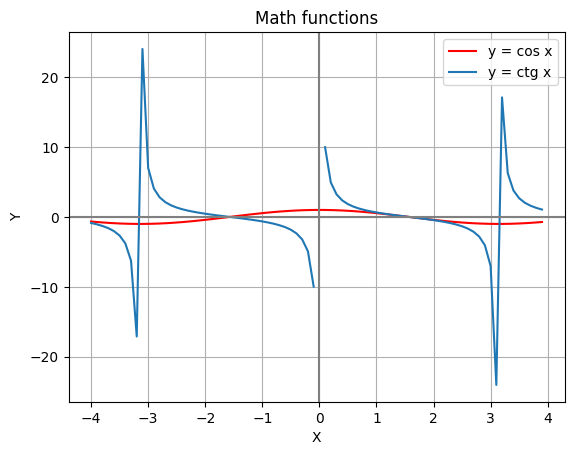

In [62]:
x = np.arange(-4, 4, 0.1)

y_1 = np.cos(x)
plt.plot(x, y_1, label='y = cos x', c='r', linestyle='-')

y_2 = np.cos(x) / np.sin(x)
y_2 = np.where(np.abs(np.sin(x)) < 1e-3, np.nan, y_2)
plt.plot(x, y_2, label='y = ctg x')

plt.title("Math functions")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.axhline(0, c='grey')
plt.axvline(0, c='grey')
plt.show()


### Задание 6 (0.5 балла)

Ранее мы уже проверили сбалансированность данных по разным категориям активностей в train и test сетах. Теперь визуализируйте количество сэмплов в каждой из категорий отдельно для train и test сетов, как в примере ниже. Проследите, чтобы порядок категорий слева и справа был одинаков. Иначе не очень удобно их сравнивать (когда они в разных местах двух графиков). Также заметьте, что в примере ось Х в одинаковом масштабе, что тоже удобно для сравнения.

Вам может пригодиться:
- plt.barh или ax.barh

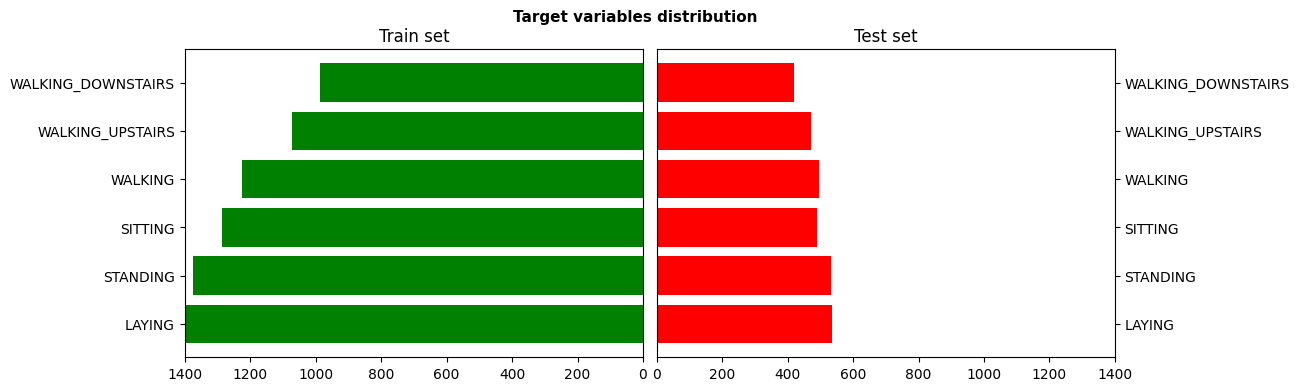

In [29]:
train_count = train_new[['Activity', 'subject']].groupby('Activity').count().sort_values(by="subject", ascending=False)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

categories = np.array(train_count.index)
values = np.array(train_count["subject"])
bars = ax1.barh(categories, values, color='green')
ax1.set_title("Train set")
ax1.set_xticks(np.arange(0, 1500, 200))
ax1.invert_xaxis()

test_count = test_new[['Activity', 'subject']].groupby('Activity').count().loc[categories]

categories = np.array(test_count.index)
values = np.array(test_count["subject"])
bars = ax2.barh(categories, values, color='red')
ax2.set_xticks(np.arange(0, 1500, 200))
ax2.set_title("Test set")
ax2.yaxis.tick_right()

ax1.set_xlim(1400, 0)
ax2.set_xlim(0, 1400)
plt.subplots_adjust(wspace=0.03)
fig.suptitle('Target variables distribution', fontsize=11, fontweight='bold')
plt.show()

Правда на таких графиках проще проверять баланс классов таргета?)

### Задание 7 (0.5 балла)

Ранее вы выводили таблицу корреляций. Однако просто таблица корреляций не очень удобна для анализа. Что, если признаков было бы больше? Визуализируйте heatmap корреляций. Подпишите значения корреляций, округленные до 2 знаков после запятой, на графике и оставьте только те значения, которые по модулю не меньше 0.5. Будем считать такие корреляции существенными. Если будете брать код из семинарского ноутбука, то поменяйте в нем что-нибудь, например, цветовую гамму, иначе проверяющий будет карать :)

Какой признак стоит исключить из рассмотрения корреляций? Напишите его название, а также причину, почему нет смысла его рассматривать.

Вам может пригодиться:
- sns.heatmap
- методы get_text и set_text у атрибута texts графика

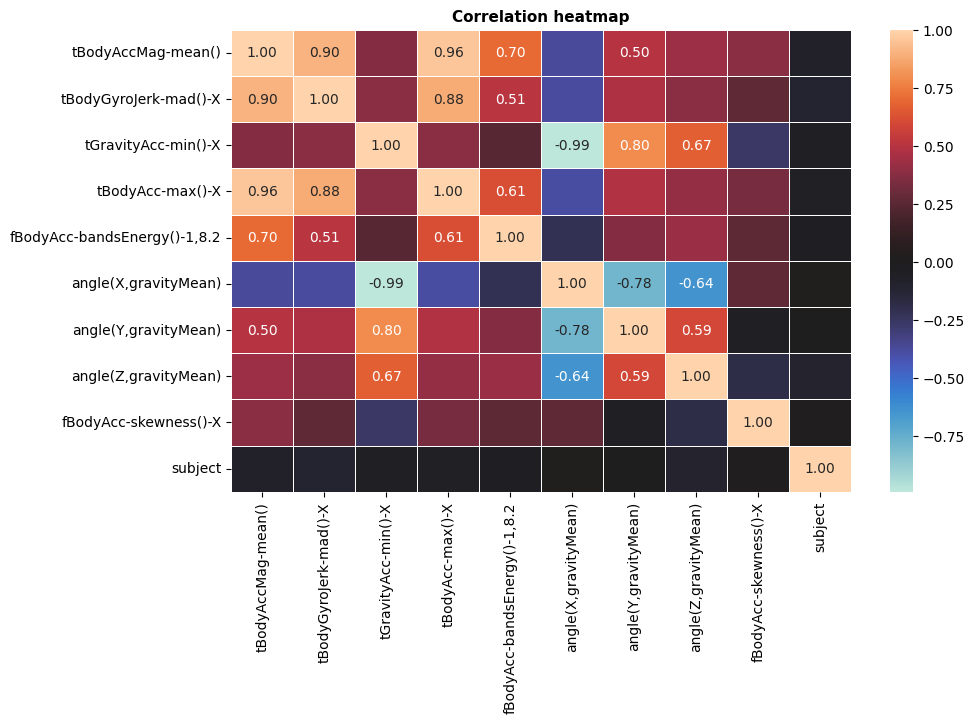

In [63]:
table = plt.subplots(figsize=(10, 6))
axe = sns.heatmap(train_new.corr(numeric_only=True), cmap="icefire", annot=True, fmt="0.2f", linewidth=.65)
for i in axe.texts:
    if abs(float(i.get_text())) >= 0.5:
        i.set_text(i.get_text())
    else:
        i.set_text("")
plt.title("Correlation heatmap",fontsize=11, fontweight='bold')
plt.show()


Я считаю, что стоит убрать subject, потому что этот признак отвечает за номер участника, и он не имеет какой-то статистической значимости, просто присвоили номер участнику, и он не коррелирует ни содним из других признаков. Можно заметить на графике, что всё почти в нуле, чёрное. 

### Задание 8 (0.5 балла)

Для начала будем стрелять из пушки по воробьям. Выведите pairplot по всем данным train сета. Напишите, заметили ли вы в нем что-нибудь интересное, чего не было в таблицах и графиках ранее, а также сообщите, было ли вам удобно анализировать 100 графиков.

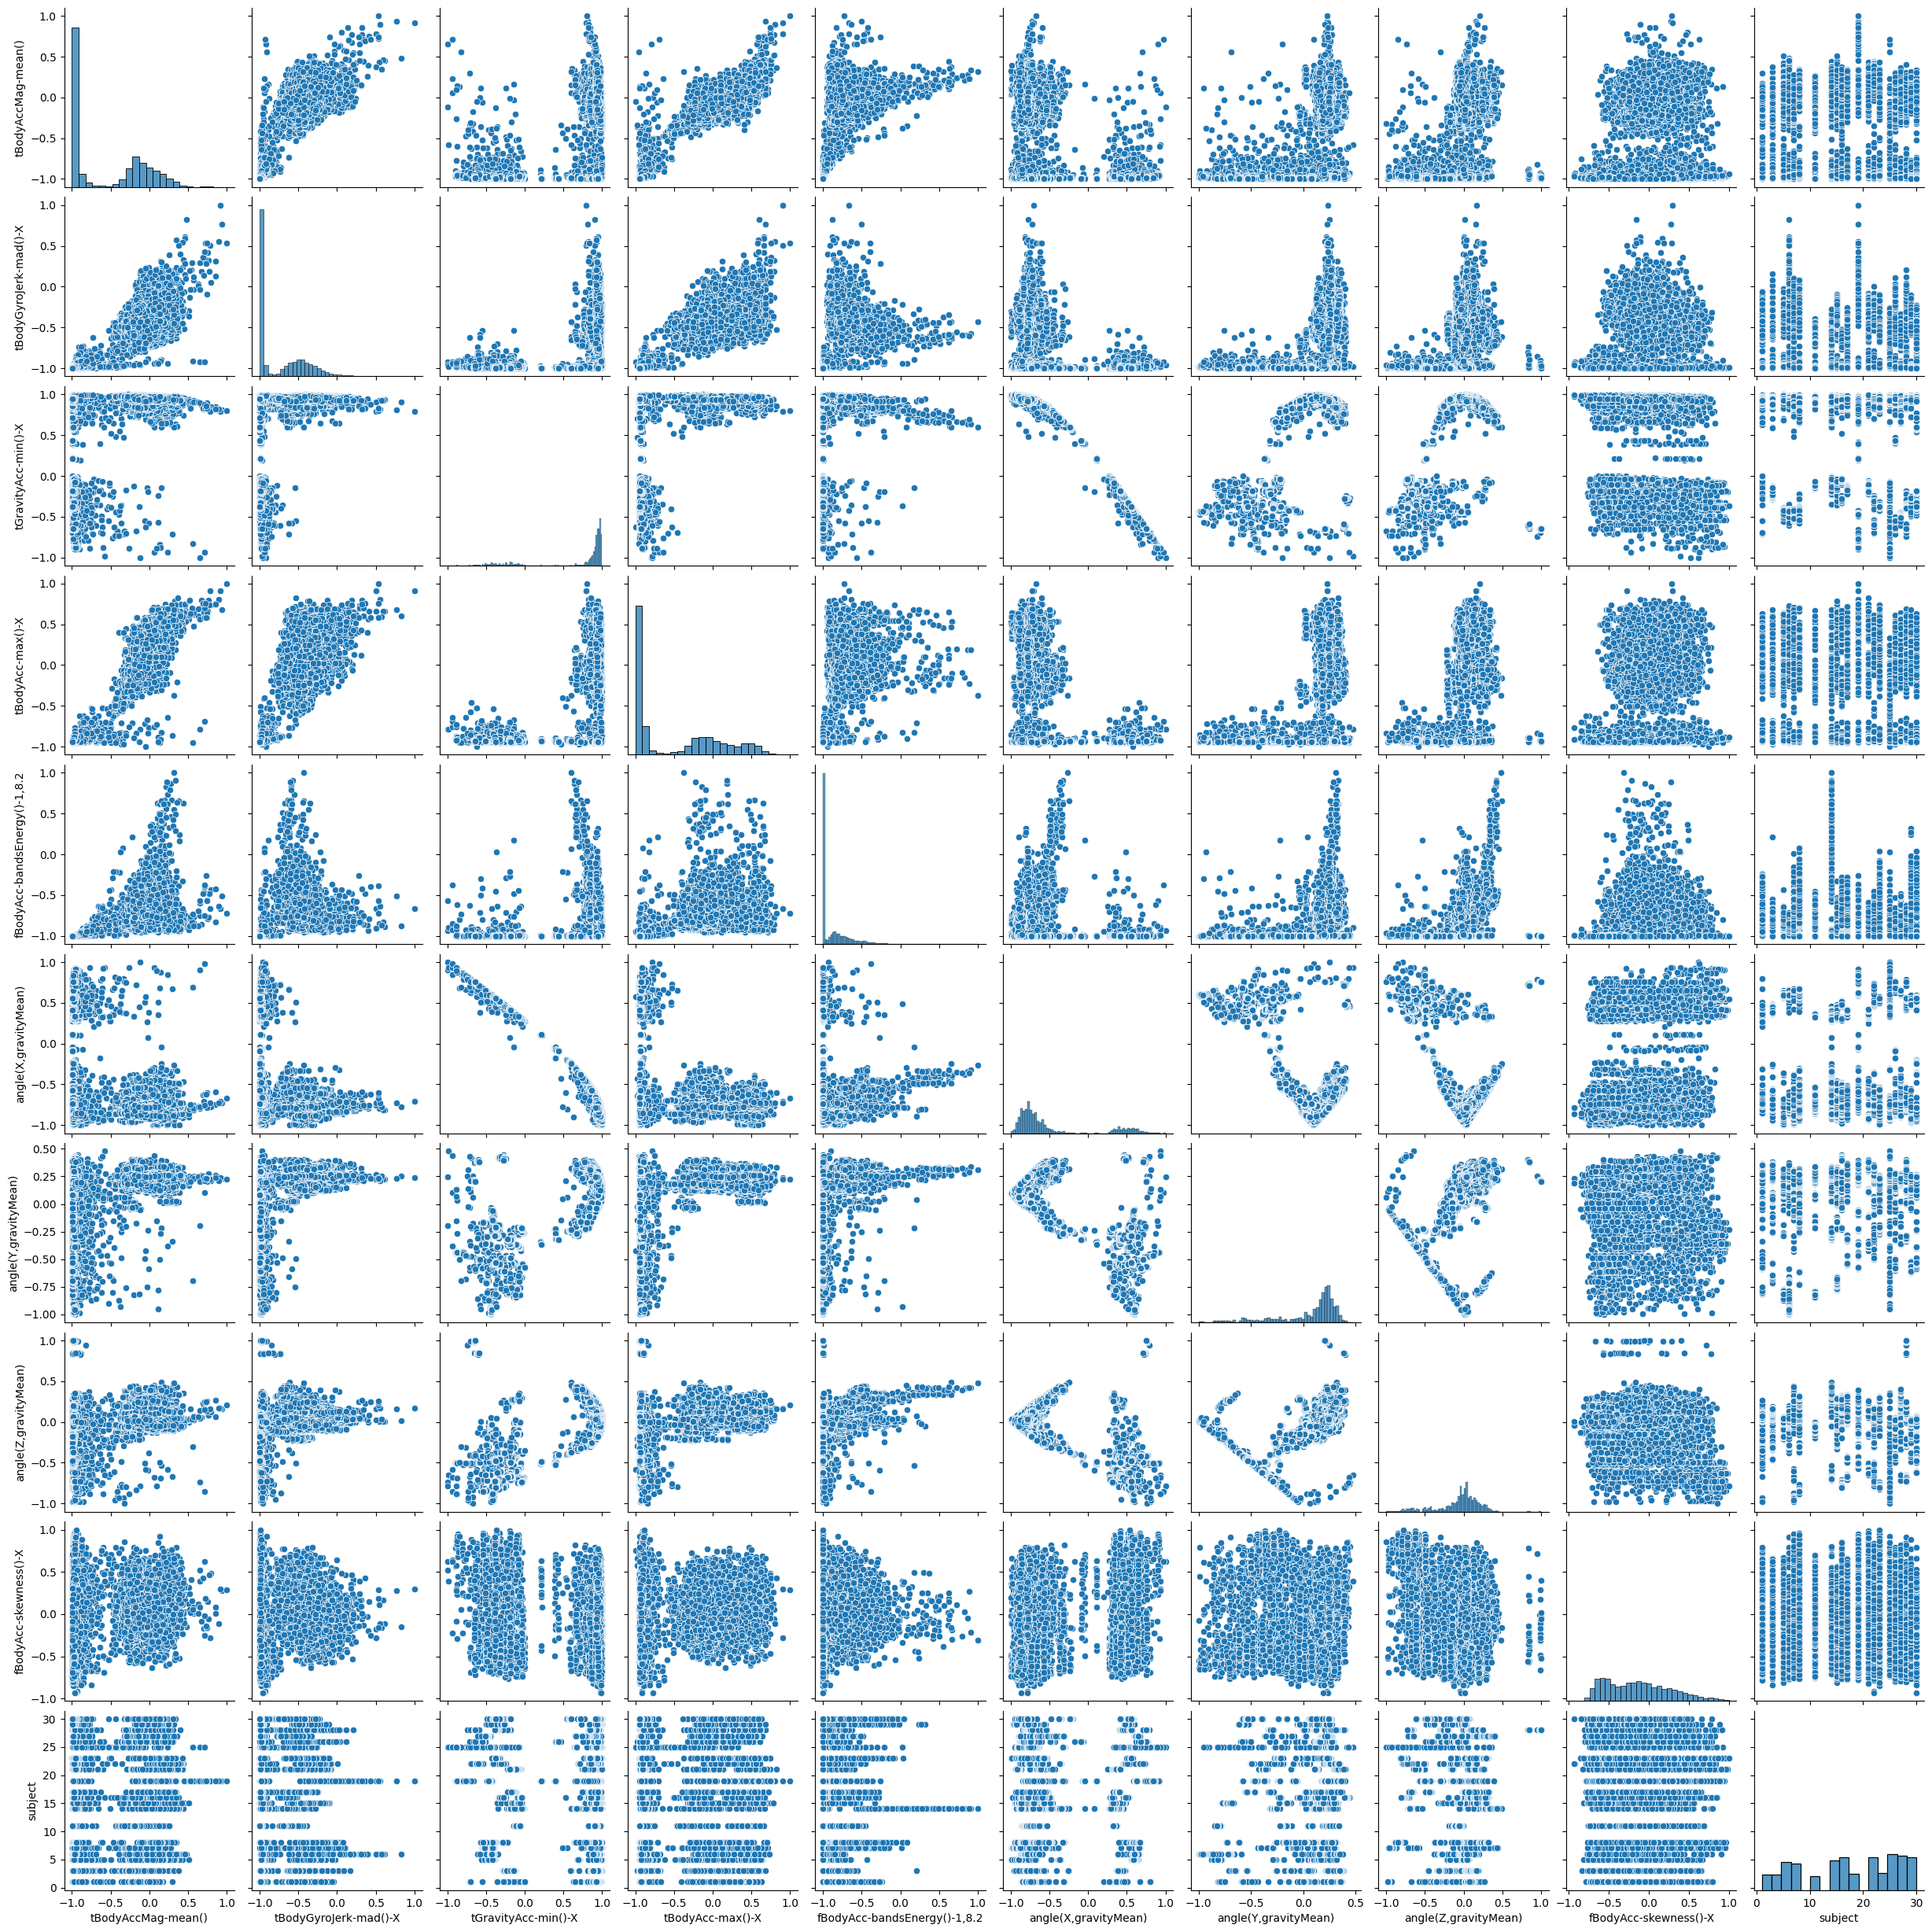

In [64]:
diagram_big = sns.pairplot(train_new)
diagram_big


Теперь на главной диагонали не просто 1, как в корреляции, а столбчатые диаграммы. Subject не похож на другие диаграммы, скорее имеющие форму облака, а тут возникают линии, что связано со смыслом признака subject, присвоение номеров участникам.
Благодаря pairplot видно, что связь нелинейная, появляются разнве изгибы, и появляется несколько режимов, то есть несколько облаков из точек, это можно объяснить тем, что разные виды активностей создают разные режимы поведения признаков.
А также, в pairplot для некоторых пар признаков точки образуют видимый линейный тренд (angle(X,gravityMean) и tGravityAcc-min()-X, к примеру). Это объяснимо, так как оба признака связаны с ориентацией о гравитации и отражают близкую физическую информацию (угол для оси X).
Для других пар (angle(Z,gravityMean) и fBodyAcc-skewness()-X), точки в форме облака. Эти признаки описывают разные аспекты данных, поэтому линейной связи может не быть или она может быть слабой.
А ещё для некоторых угловых признаков есть отчётливые геометрические формы (полосы), можно предположить, что углы ограничены диапазоном и встречаются типичные положения смартфона относительно гравитации.

100 графиков вообще было неудобно анализировать, графиков слишком много и они все мелкие.

### Задание 9 (1 балл)

Окей. Смотреть на все сразу не очень удобно. Кажется, нужно смотреть на признаки в отдельности и искать в них инсайты.

Попробуем проверить гипотезу. Отобразите плотность распределения (kde) `tBodyAccMag-mean()` для каждой из активностей, как в примере ниже. Видите закономерность? Можно ли поделить все активности на две группы? Если да, то проведите вертикальную линию, которая визуально неплохо разделяет эти группы.

Давайте первую группу называть статическими активностями, а вторую - динамическими.

Посчитайте, какую долю правильных ответов дает ваша вертикальная линия для разделения именно этих двух групп. С чем может быть связан полученный вами результат? Предположите логическое обоснование (почему именно данный признак так хорошо/плохо разделяет группы активностей).

Вам может пригодиться:
- sns.kdeplot

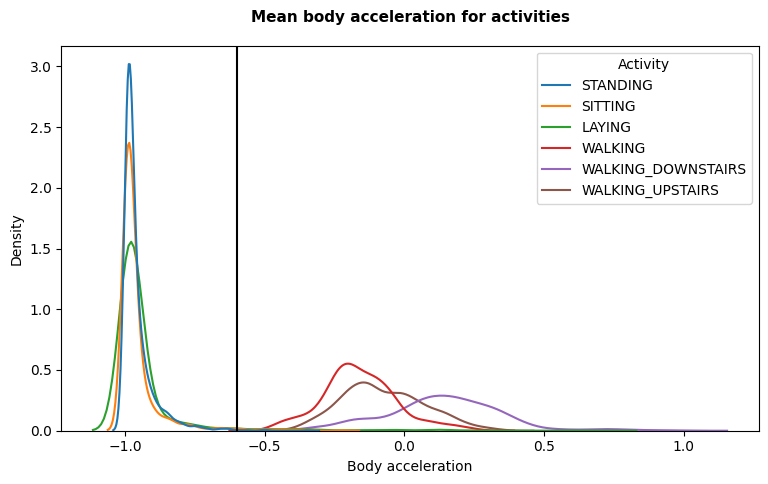

In [18]:
diagr = plt.subplots(figsize=(9, 5))
grf = sns.kdeplot(data=train_new, x="tBodyAccMag-mean()", hue='Activity')
plt.xlabel("Body acceleration")
grf.set_title("Mean body acceleration for activities", y=1.04, fontsize=11, fontweight='bold')
plt.axvline(-0.6, c='black')

In [20]:
stat = ["STANDING", "SITTING", "LAYING"]
dynam = ["WALKING", "WALKING_DOWNSTAIRS", "WALKING_UPSTAIRS"]

eurist = -0.6
train_t = train_new.copy()

train_t.loc[train_t['Activity'].isin(dynam), 'true_group'] = 1
train_t.loc[train_t['Activity'].isin(stat), 'true_group'] = 0

train_t.loc[train_t['tBodyAccMag-mean()'] > eurist, 'pred_group'] = 1
train_t.loc[train_t['tBodyAccMag-mean()'] <= eurist, 'pred_group'] = 0

match = (train_t['true_group'] == train_t['pred_group']).mean()
print(f'The proportion of correct answers is {match:.4f}')

The proportion of correct answers is 0.9895


Признак tBodyAccMag-mean() хорошо разделяет активности на статические и динамические (почти 99%), поскольку он отражает среднюю величину ускорения тела в окне наблюдения. При динамических активностях появляются регулярные импульсы и резкие изменения ускорения, поэтому движение выражено сильнее, соответственно значения этого признака отличаются от значений у статических активностей. При статических активностях почти нет поступательных движений, и ускорение разнится около небольших значений, движение выражено слабее.
На контрасте с угловыми признаками, которые сильнее зависят от ориентации телефона, значение ускорения более напрямую связано с интенсивностью движения, соответственно он нагляднее разделяет статику и динамику. Результат не до конца идеален из-за частичного пересечения распределений.

### Задание 10 (0.5 балла)

Поздравляем, вы проверили первую гипотезу в процессе EDA. Однако нам бы хотелось уметь не группы разделять, а каждый отдельный вид активности. Попробуйте нарисовать "ящики с усами" для `angle(X,gravityMean)` с разделением по разным видам активности на данных train. Можно ли сделать какой-то вывод по полученной визуализации? Проанализируйте и проинтерпретируйте полученные картинки (если заметили какую-то особенность, может какая-то категория значительно выделяется, то предположите, почему так могло произойти).

Вам может пригодиться:
- sns.boxplot

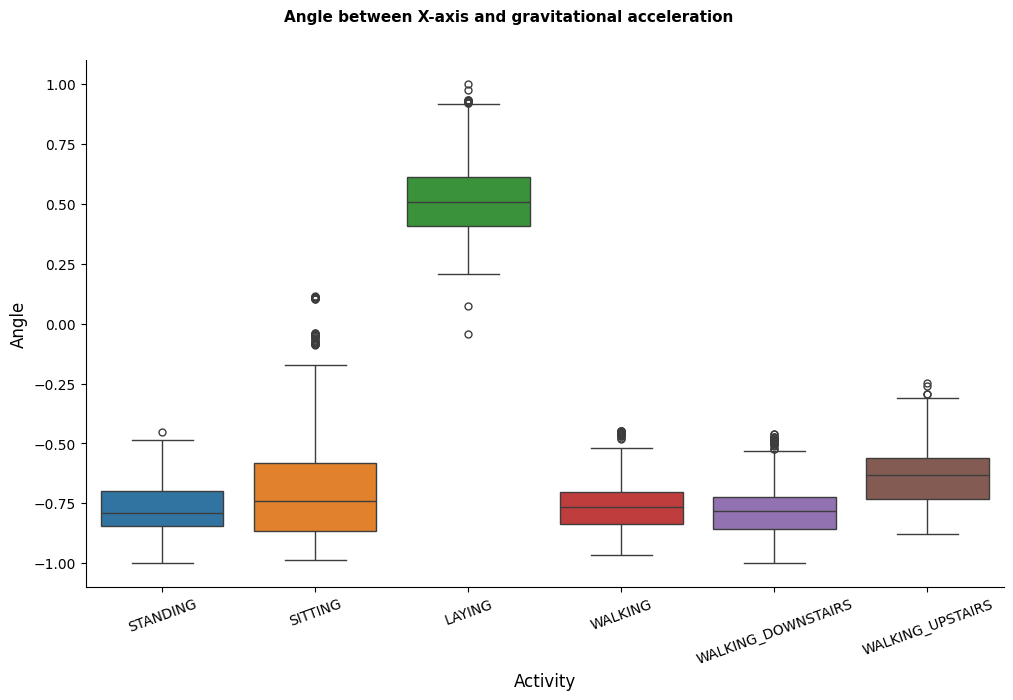

In [65]:
order = [ "STANDING", "SITTING", "LAYING", "WALKING", "WALKING_DOWNSTAIRS", "WALKING_UPSTAIRS"]

grf = sns.catplot(x="Activity", y="angle(X,gravityMean)", hue='Activity', data=train_new, kind="box", order=order, height=6, aspect=1.7)

grf.figure.suptitle("Angle between X-axis and gravitational acceleration", y=1.06, fontsize=11, fontweight='bold')
grf.set_axis_labels("Activity", "Angle", fontsize=12)
grf.set_xticklabels(rotation=20)

grf


Из особенностей выделяется активность "LAYING", в отличие от других, у неё медиана больше нуля. Это можно объяснить тем, что тело находится в горизонтальном положении, когда мы лежим, тогда как для остальных признаков тело находится хоть солько-нибудь, но в вертикальном положении. Ещё в связи с той же особенностью выделяются наблюдения "SITTING" и "WALKING_UPSTAIRS", у них более близкая к нулю медиана и большой межквартильный размах, и при этих активностях положение тела тоже отличается, но всё же при "лежании" самое сильное отличие от других активностей.

### Задание 11 (0.5 балла)

Посмотрим теперь на `tBodyAcc-max()-X`. Визуализируйте скрипичные диаграммы для этого признака с разделением по активностям на всем train. Кажется логичным, что максимальное ускорение в моменте для разных активностей будет различаться. Однако есть ли активность, которая будет выделяться? Если да, то предложите объяснение, почему эта активность выделяется.

Вам может пригодиться:
- sns.violinplot

<Axes: title={'center': 'Maximal body acceleration over activities'}, xlabel='Activity', ylabel='Maximal acceleration'>

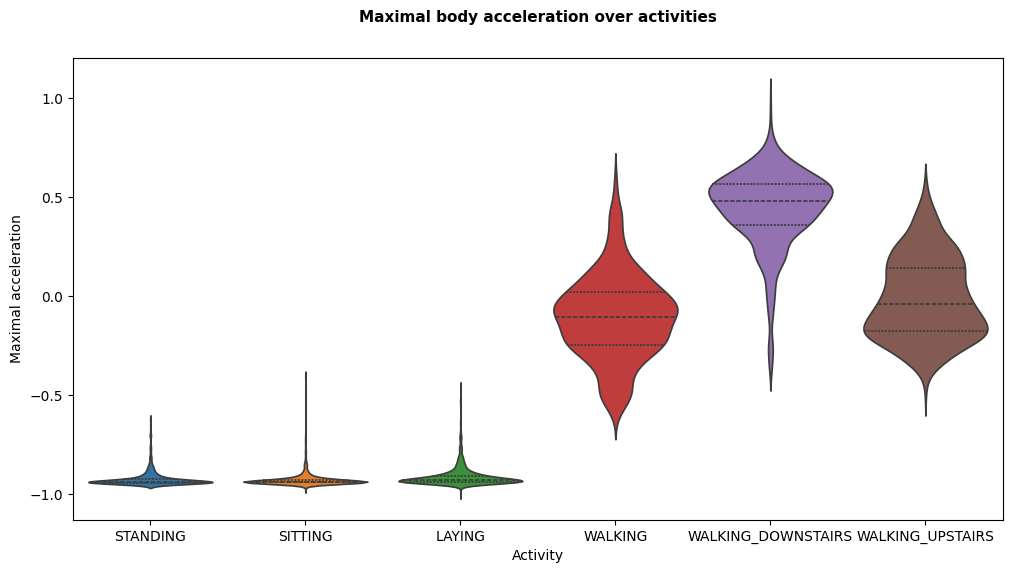

In [24]:
fig = plt.subplots(figsize=(12, 6))

diagram = sns.violinplot(data=train_new, x="Activity", y="tBodyAcc-max()-X", hue="Activity", inner="quart")
diagram.set_title("Maximal body acceleration over activities", y=1.06, fontsize=11, fontweight='bold')  
plt.ylabel("Maximal acceleration") 

diagram

Активность, которая выделяет среди других это "WALKING_DOWNSTAIRS", у этой активности значения максимального ускорения в моменте выше, чем у других активностей (при учёте знака). Это можно объяснить тем, что при спуске по лестнице движения могут быть более резкими, а дополнительное ускорение придается гравитацией, это ускоряет движение участника. А также можно предположить, что при спуске по лестнице смартфон или тело участника сильнее подпрыгивает, за счёт чего максимальные значения признака становятся выше.

### Задание 12 (1 балл)

Вы уже можете с довольно хорошим качеством выделить две категории активности из шести. Продолжим.

Ранее уже упоминалось разделение на две группы активностей: статические и динамические. Пришла пора разделить датасет train на две части. Сделайте это! Теперь на одной картинке покажите распределения `fBodyAcc-bandsEnergy()-1,8.2` для динамичных активностей (`boxenplot` - немного измененый "ящик с усами") и `angle(Y,gravityMean)` для статических - тут хватит и простой гистограммы (прямо, как в примере ниже). Можно ли выделить еще какие-то активности? Если да, напишите, какие активности на 1 и 2 графиках выделяются.

Вам может пригодиться:
- plt.subplots или matplotlib.gridspec (заметили, что один график больше другого? попробуйте сами так сделать - вам понравится...)
- sns.boxenplot
- sns.histplot

Text(0.5, 0.98, 'Angle and Energy for activity groups')

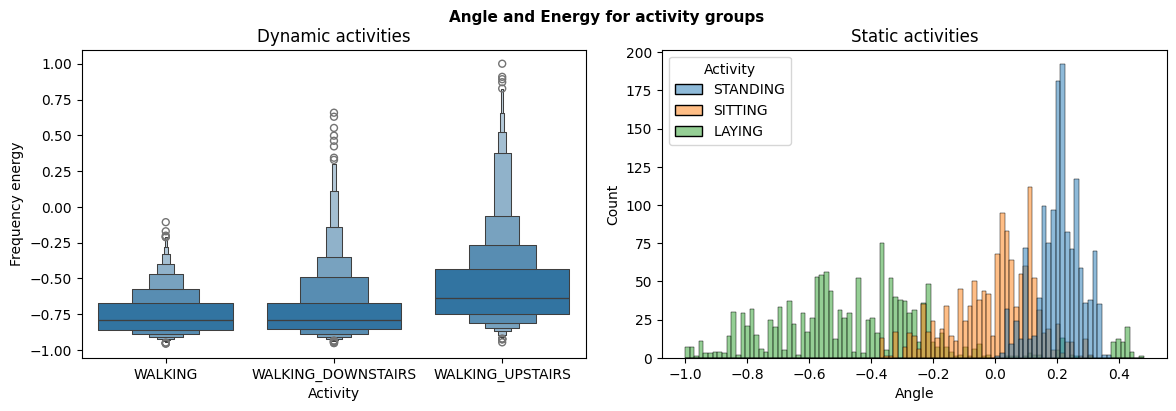

In [14]:
stat = ["STANDING", "SITTING", "LAYING"]
dynam = ["WALKING", "WALKING_DOWNSTAIRS", "WALKING_UPSTAIRS"]

stat_1 = train_new[train_new["Activity"] == "STANDING"]
stat_2 = train_new[train_new["Activity"] == "SITTING"]
stat_3 = train_new[train_new["Activity"] == "LAYING"]
st = pd.concat([stat_1, stat_2, stat_3])

dynam_1 = train_new[train_new["Activity"] == "WALKING"]
dynam_2 = train_new[train_new["Activity"] == "WALKING_DOWNSTAIRS"]
dynam_3 = train_new[train_new["Activity"] == "WALKING_UPSTAIRS"]
dy = pd.concat([dynam_1, dynam_2, dynam_3])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1 = sns.boxenplot(data=dy, x="Activity", y="fBodyAcc-bandsEnergy()-1,8.2", ax=ax1)
ax1.set_title("Dynamic activities")
ax1.set_ylabel("Frequency energy")

ax2 = sns.histplot(data=st, x="angle(Y,gravityMean)", hue='Activity', binwidth=0.015, ax=ax2)
ax2.set_title("Static activities")
plt.xlabel("Angle")
plt.subplots_adjust(wspace=0.15)
fig.suptitle('Angle and Energy for activity groups', fontsize=11, fontweight='bold')

Можно выделить "WALKING_DOWNSTAIRS" в первой группе, у этой активности медиана выше, чем у других активностей, и выделяется "STANDING" во второй группе, так как данные достигают высшей оценки среди других активностей и они плотно скомпанованы в небольшом диапазоне примерно от 0.0 до 0.3.


### Задание 13 (0.5 балла)

Не всегда жизнь будет такой легкой, а данные будут полностью или почти линейно разделимы в одному признаку (иначе чем бы занимались дата саентисты...). Часто данные вообще ни по одному признаку нельзя адекватно разделить (да и по комбинациям признаков тоже). Давайте попробуем взять не один признак, а целых два!

Рассмотрим только статические активности. Будет снова два графика сразу. На первом графике будет боксплот распределения `fBodyAcc-skewness()-X` по активностям. А на втором попробуем взять не все наблюдения данной группы активностей, а только их часть. Разделимы ли категории по `fBodyAcc-skewness()-X`? А если взять только те строки, где `fBodyAcc-skewness()-X < -0.376`, и теперь вывести боксплот распределения `angle(Y,gravityMean)` по разным активностям? Попробуйте и напишите, выделилась ли какая-то категория?

Вам может пригодиться:
- plt.subplots или matplotlib.gridspec
- sns.boxplot

Text(0.5, 0.98, 'Acceleration and Gravity over static activities')

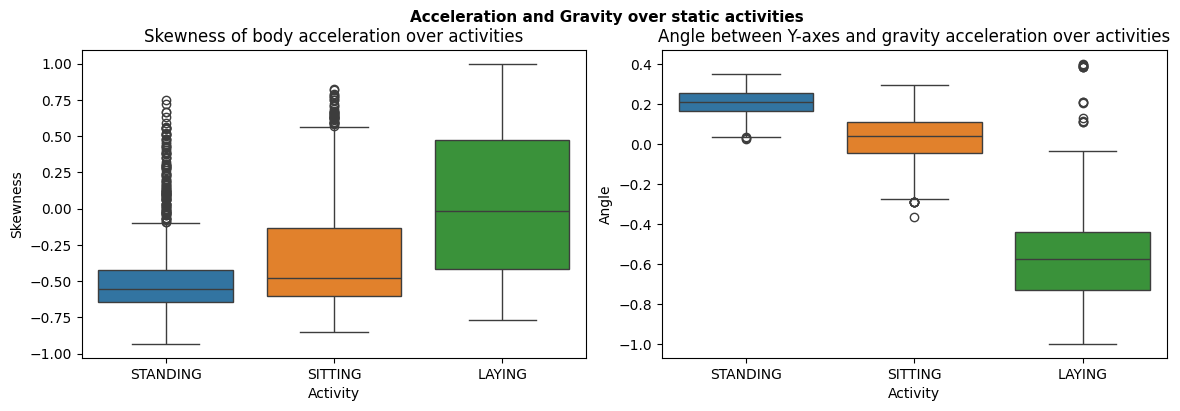

In [67]:
st_1 = train_new[train_new["Activity"] == "STANDING"]
st_2 = train_new[train_new["Activity"] == "SITTING"]
st_3 = train_new[train_new["Activity"] == "LAYING"]
statistic = pd.concat([st_1, st_2, st_3])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1 = sns.boxplot(data=statistic, x="Activity", y="fBodyAcc-skewness()-X", hue="Activity", ax=ax1)
ax1.set_title("Skewness of body acceleration over activities")
ax1.set_ylabel("Skewness")

big_sta = statistic[statistic['fBodyAcc-skewness()-X'] < - 0.376]

ax2 = sns.boxplot(data=big_sta, x="Activity", y='angle(Y,gravityMean)', hue="Activity", ax=ax2)
ax2.set_title("Angle between Y-axes and gravity acceleration over activities")
ax2.set_ylabel("Angle")
plt.subplots_adjust(wspace=0.15)

fig.suptitle('Acceleration and Gravity over static activities', fontsize=11, fontweight='bold')

Категории по fBodyAcc-skewness()-X не разделимы. Каких-то выделяющихся закономерностей среди данных нет, их медианные значения близки друг с другом. Заметно достаточно большое количество выбросов и высокий межквартильный размах. 
На втором графике заметнее выделяется "LAYING", у этой активности очень маленьким межквартильным размах и значительно более высокая медиана, чего нельзя сказать о других графиках, а ещё при 'лежании' ориентация смартфона отличается, соответственно и распределение угла сдвигается. На втором графике "LAYING" ушёл сильно в отрицательные значения.
Ещё фильтр fBodyAcc-skewness()-X < -0.376 как бы пытается выделить подмножество наблюдений, где форма распределения ускорения похожа, чтобы сравнить, отделятся ли активности по другому признаку angle(Y,gravityMean).

Поздравляем, теперь вы на шажок ближе к тому, чтобы стать решающим деревом!

### Задание 14 (1 балл)

Вот и осталась лишь одна активность, которую мы никак не выделили. Попробуем и ее какими-то порогами отделить от всех остальных. Да, можно было бы сказать, что, раз уж мы выделили 5 из 6 категорий, то все остальное - это и есть последняя категория, но мы не идем легкими путями. Выделить оставшуюсь категорию с хорошим качеством не так уж и просто. Из доступных признаков, сначала посмотрите на распределение `tBodyAcc-max()-X` на динамических активностях (скрипичная диаграмма отлично подойдет).

А теперь спускаем вам порог `tBodyAcc-max()-X < 0.157`. Для таких строк постройте диаграмму рассеяния для признака `tGravityAcc-min()-X`. Да, получается неидеально, но это честная работа. Можно выбрать порог так, чтобы чисто из таблицы с динамическими активностями из строк, где `tBodyAcc-max()-X < 0.157`, выбрать по некоторому порогу для `tGravityAcc-min()-X` строки так, чтобы доля правильных ответов на оставшейся категории была не меньше 83%!

Вам может пригодиться:
- plt.subplots или matplotlib.gridspec
- sns.violinplot
- sns.swarmplot (иногда лучше подходит, чем просто sns.scatterplot)

Обратите внимание, что подписи к осям можно убирать методами plt. Например, если у вас общее название для оси Y для обоих графиков, то можно не подписывать ось Y у второго графика.

Text(0.5, 0.98, 'Acceleration and Gravity over dynamic activities')

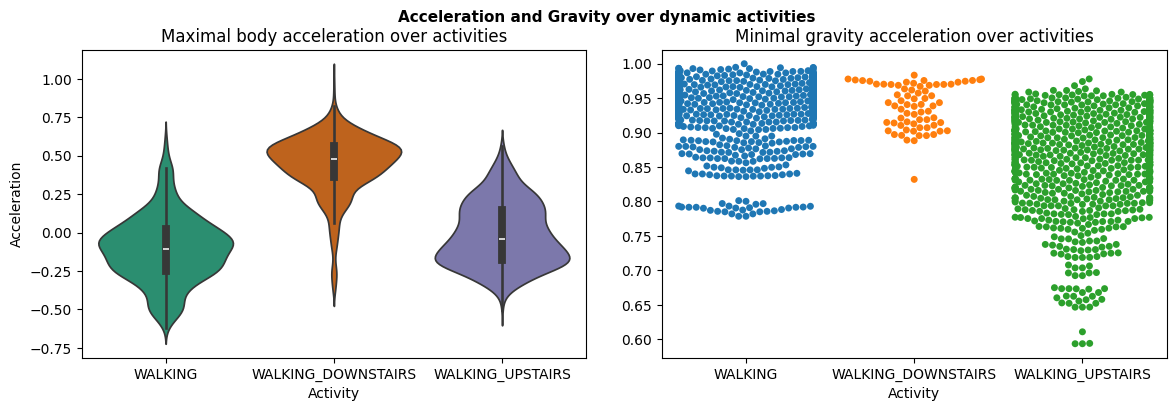

In [68]:
dy_1 = train_new[train_new["Activity"] == "WALKING"]
dy_2 = train_new[train_new["Activity"] == "WALKING_DOWNSTAIRS"]
dy_3 = train_new[train_new["Activity"] == "WALKING_UPSTAIRS"]

dym = pd.concat([dy_1, dy_2, dy_3])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1 = sns.violinplot(data=dym, x="Activity", y="tBodyAcc-max()-X", hue="Activity", palette="Dark2", ax=ax1)
ax1.set_title("Maximal body acceleration over activities")
ax1.set_ylabel("Acceleration")

dynam = dym[dym['tBodyAcc-max()-X'] < 0.157]
ax2 = sns.swarmplot(data=dynam, x="Activity", y="tGravityAcc-min()-X", hue='Activity', ax=ax2)
ax2.set_title("Minimal gravity acceleration over activities")
ax2.set_ylabel('') 

plt.subplots_adjust(wspace=0.15)
fig.suptitle('Acceleration and Gravity over dynamic activities', fontsize=11, fontweight='bold')

In [51]:
dy_1 = train_new[train_new["Activity"] == "WALKING"]
dy_2 = train_new[train_new["Activity"] == "WALKING_DOWNSTAIRS"]
dy_3 = train_new[train_new["Activity"] == "WALKING_UPSTAIRS"]

dy = pd.concat([dy_1, dy_2, dy_3])
dynam = dy[dy['tBodyAcc-max()-X'] < 0.157]
dynnam_cop = dynam.copy()

dynnam_cop.loc[dynnam_cop['Activity'] == "WALKING_DOWNSTAIRS", 'Activity'] = 1
dynnam_cop.loc[dynnam_cop['Activity'] != 1, 'Activity'] = 0
dynnam_cop.loc[(dynnam_cop['tGravityAcc-min()-X'] > 0.974),'tGravityAcc-min()-X'] = 1
dynnam_cop.loc[dynnam_cop['tGravityAcc-min()-X'] != 1,'tGravityAcc-min()-X'] = 0

res = np.array(dynnam_cop['tGravityAcc-min()-X'])
tar = np.array(dynnam_cop['Activity'])
(res == tar).mean()

np.float64(0.8495266567015446)

Доля правильных ответов на оставшейся категории получилась почти 85%, что не меньше 83%, так что всё сработало.

### Задание 15 (0.5 балла)

Теперь попробуем более интерактивные графики. Установите библиотеку `plotly` (обычно `pip install plotly` или `conda install plotly`). Синтаксис очень похож на `seaborn`, но вот [документация для plotly.express](https://plotly.com/python-api-reference/plotly.express.html).

Сначала подготовим данные для визуализации. Будем считать t-SNE просто "черным ящиком", который принимает наши данные и проецирует их в двумерное или трехмерное пространство. Возможно, придется немного подождать.

In [43]:
import plotly.express as px

from sklearn.manifold import TSNE

In [44]:
%%time
from sklearn.manifold import TSNE
tsne = TSNE(random_state=666, n_components=2)
new = tsne.fit_transform(train.drop(['subject', 'Activity'], axis=1))
df_2_comp = pd.concat([
    pd.DataFrame(new, columns=['x', 'y']),
    train['Activity']
], axis=1)

tsne = TSNE(random_state=666, n_components=3)
new = tsne.fit_transform(train.drop(['subject', 'Activity'], axis=1))
df_3_comp = pd.concat([
    pd.DataFrame(new, columns=['x', 'y', 'z']),
    train['Activity']
], axis=1)

CPU times: user 3min 54s, sys: 44.9 s, total: 4min 39s
Wall time: 29.5 s


Теперь нарисуйте scatter-график через `plotly.express` для `df_2_comp` с выделением цветами активностей. Красиво получилось? Видны скопления точек одного цвета? Можно разные активности отделить линиями на данном графике?

In [45]:
px.scatter(df_2_comp, x="x", y="y", color="Activity", title="2D Activities")

График получился и правда красивый. Видно, что распределения точек одного цвета, по сути одних активностей. Они похожи на кластеры, которые вполне можно отделить линиями (на статические и динамические), значит и отделить различные активности тоже можно. При этом некоторые динамические активности расположены ближе друг к другу и частично пересекаются, из-за полностью идеального разделения не будет.

Мы не отстаем от трендов и тоже можем в 3D. Сейчас и вы научитесь (если еще не умеете). Нарисуйте scatter_3d-график через `plotly.express` для `df_3_comp` с выделением цветами активностей. Повращайте его. Нормально получилось? Есть ли какая-то структура у точек?

In [47]:
fig = px.scatter_3d(data_frame=df_3_comp, x="x", y="y", z="z", color="Activity",title='3D Activities')
fig.show()

У меня создался 3D-график, у него структура данных видна ещё лучше. У него точки сгруппированы по цветам (по активностям), поэтому кластеры активностей более различимы, и разделение между группами тоже.
Можно заметить, что точки сливаются, часть классов близка между собой, поэтому их разделить всё ещё сложнее, однако кластеры шести видов активностей можно отличить и выделить визуально.

### Задание 16 (1 балл)

Мы сделали вам fit. Ваша очередь сделать predict. Допишите функцию, которая принимает на вход датафрейм с признаками, а выдает вектор из предсказаний - для каждой строки датафрейма вы определяете, к какому классу принадлежит объект. Рекомендуем сразу записывать из строками, а не кодировать в числа. Дальше фукнция `accuracy_score` выдаст вам долю правильных ответов.

Подсказка: вы уже отделили категории друг от друга по каким-то признакам. Воспользуйтесь этим знанием! Используя только проведенный вами анализ можно спокойно выбить не менее 75% на train и test! Если вы получите меньше 75%, то балл будет снижен. Авторское решение (на основе всех графиков выше) выбивает 81% и 77% на train и test соответственно. [Шпаргалка с готовыми идеями для такой задачи](https://rutube.ru/video/c6cc4d620b1d4338901770a44b3e82f4/)

In [27]:
def predict(df: pd.DataFrame):
    pred = pd.Series(index=df.index, dtype="object")

    is_dynamic = df["tBodyAccMag-mean()"] > -0.49
    is_static = ~is_dynamic

    pred.loc[is_static & (df["angle(X,gravityMean)"] > 0)] = "LAYING"
    pred.loc[is_static & pred.isna() & (df["angle(Y,gravityMean)"] > 0.1) & (df["angle(Y,gravityMean)"] < 0.6)] = "STANDING"
    pred.loc[is_static & pred.isna()] = "SITTING"

    
    pred.loc[is_dynamic & (df["tBodyAcc-max()-X"] > 0.32)] = "WALKING_DOWNSTAIRS"
    pred.loc[is_dynamic & pred.isna() & (df["fBodyAcc-bandsEnergy()-1,8.2"] > -0.85)] = "WALKING_UPSTAIRS"
    pred.loc[is_dynamic & pred.isna() & (df["tGravityAcc-min()-X"] > 0.6)] = "WALKING"

    pred.loc[is_dynamic & pred.isna()] = "WALKING"

    return pred.values


def accuracy_score(y_true, y_pred) -> float:
    y_true = np.asarray(y_true).reshape(-1, 1)
    y_pred = np.asarray(y_pred).reshape(-1, 1)
    return (y_true == y_pred).mean()

In [28]:
x_train = train.drop(columns="Activity")
y_train = train["Activity"]

x_test = test.drop(columns="Activity")
y_test = test["Activity"]

train_preds = predict(x_train)
test_preds = predict(x_test)

print(f"Accuracy on train set => {accuracy_score(y_train, train_preds):.4f}")
print(f"Accuracy on test set => {accuracy_score(y_test, test_preds):.4f}")

Accuracy on train set => 0.7722
Accuracy on test set => 0.7601


__Место для мема и/или фидбэка__

Это домашка прям совсем другая по ощущениям, нежели две предыдущие. Было одновременно и интереснее, и сложнее. Однозначно могу сказать то, что с этого момента картина того, что требуется и какие вообще есть задачи становятся понятнее. 
Спасибо за проверку домашек, всего доброго!  :D 